# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 25 - 3er bimestre 2026

## **Alumno 1:** Nicolás Tonnelier

## **Alumno 2:** Marina Racciatti

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 7 de agosto (hora de Argentina)**.

La resolución del TP debe realizarse en **parejas**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que ambos deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta. También está permitido realizar el trabajo de forma **individual** si así lo desean, aunque esta modalidad no es la más recomendable.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/dLacTc6eZMWjWGZJA)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP2-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP2-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [1]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn

sns.set_theme(style="whitegrid")
# warnings.filterwarnings("ignore", message="For backward compatibility.*")

df = pd.read_csv("dataset/adult_train.csv")

df.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  str  
 2   education       30162 non-null  str  
 3   marital-status  30162 non-null  str  
 4   occupation      30162 non-null  str  
 5   relationship    30162 non-null  str  
 6   race            30162 non-null  str  
 7   sex             30162 non-null  str  
 8   capital-gain    30162 non-null  int64
 9   capital-loss    30162 non-null  int64
 10  hours-per-week  30162 non-null  int64
 11  skill-profile   30162 non-null  str  
 12  native-country  30162 non-null  str  
 13  income          30162 non-null  str  
dtypes: int64(4), str(10)
memory usage: 3.2 MB


In [3]:
df.describe()

,age,capital-gain,capital-loss,hours-per-week
count,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1092.007858,88.372489,40.931238
std,13.134665,7406.346497,404.298370,11.979984
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,47.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


### Chequeo de datos

Buscamos nulls y duplicados.

In [4]:
val_df = pd.read_csv("dataset/adult_val.csv")

print("Valores nulos en train:", df.isnull().sum().sum())
print(f"Filas duplicadas en train: {df.duplicated().sum()} ({df.duplicated().mean():.2%})")
print(f"Filas duplicadas en val:   {val_df.duplicated().sum()} ({val_df.duplicated().mean():.2%})")
print("\nShape train:", df.shape, "| Shape val:", val_df.shape)

Valores nulos en train: 0
Filas duplicadas en train: 479 (1.59%)
Filas duplicadas en val:   118 (0.78%)

Shape train: (30162, 14) | Shape val: (15060, 14)


No hay valores nulos. Sí hay algunas filas duplicadas (~1.6% en train, ~0.8% en val), pero como el dataset no incluye un `id` único, es posible que se trate de individuos que comparten exactamente el mismo perfil (misma edad, educación, ocupación, horas trabajadas, etc.). Por lo que las conservamos.

### Cardinalidad de las variables categóricas

Valores únicas en variables categóricas:

In [5]:
df.select_dtypes(include='object').nunique()

/var/folders/2v/hsj6hmz12mn3969pmvbykhf40000gn/T/ipykernel_51586/3404847108.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()


workclass          7
education         16
marital-status     7
occupation        14
relationship       6
race               5
sex                2
skill-profile     80
native-country    41
income             2
dtype: int64

Consideramos de alta cardinalidad a toda variable con 10 o más valores únicos. Clasificamos cada variable categórica (excluyendo el target `income`) según ese criterio:

In [6]:
cat_cols = df.select_dtypes(include='object').columns.drop('income')
cardinality = df[cat_cols].nunique().sort_values()

low_card = cardinality[cardinality < 10]
high_card = cardinality[cardinality >= 10]

print("Baja cardinalidad:")
print(low_card)
print("\nAlta cardinalidad:")
print(high_card)

Baja cardinalidad:
sex               2
race              5
relationship      6
workclass         7
marital-status    7
dtype: int64

Alta cardinalidad:
occupation        14
education         16
native-country    41
skill-profile     80
dtype: int64


/var/folders/2v/hsj6hmz12mn3969pmvbykhf40000gn/T/ipykernel_51586/522505854.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.drop('income')


`education` entra en el grupo de alta cardinalidad por conteo (16 valores), pero sus categorías tienen un orden vinculado al nivel educativo creciente. Por eso en lugar de aplicarle hot-encoding usamos codificación ordinal:

In [7]:
education_categories = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
    'HS-grad', 'Assoc-acdm', 'Assoc-voc', 'Some-college', 'Bachelors', 'Prof-school', 'Masters', 'Doctorate'
]

assert set(education_categories) == set(df['education'].unique())
education_categories

['Preschool',
 '1st-4th',
 '5th-6th',
 '7th-8th',
 '9th',
 '10th',
 '11th',
 '12th',
 'HS-grad',
 'Assoc-acdm',
 'Assoc-voc',
 'Some-college',
 'Bachelors',
 'Prof-school',
 'Masters',
 'Doctorate']

Inspeccionamos la frecuencia de cada categoría:

In [8]:
for col in low_card.index:
    print(f"--- {col} ({df[col].nunique()} valores) ---")
    print(df[col].value_counts())
    print()

--- sex (2 valores) ---
sex
Male      20380
Female     9782
Name: count, dtype: int64

--- race (5 valores) ---
race
White                 25933
Black                  2817
Asian-Pac-Islander      895
Amer-Indian-Eskimo      286
Other                   231
Name: count, dtype: int64

--- relationship (6 valores) ---
relationship
Husband           12463
Not-in-family      7726
Own-child          4466
Unmarried          3212
Wife               1406
Other-relative      889
Name: count, dtype: int64

--- workclass (7 valores) ---
workclass
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64

--- marital-status (7 valores) ---
marital-status
Married-civ-spouse       14065
Never-married             9726
Divorced                  4214
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spo

In [9]:
for col in high_card.drop('education').index:
    vc = df[col].value_counts()
    print(f"--- {col} ({df[col].nunique()} valores) ---")
    print("Más frecuentes:")
    print(vc.head(5))
    print("Menos frecuentes:")
    print(vc.tail(5))
    print()

--- occupation (14 valores) ---
Más frecuentes:
occupation
Prof-specialty     4038
Craft-repair       4030
Exec-managerial    3992
Adm-clerical       3721
Sales              3584
Name: count, dtype: int64
Menos frecuentes:
occupation
Farming-fishing    989
Tech-support       912
Protective-serv    644
Priv-house-serv    143
Armed-Forces         9
Name: count, dtype: int64

--- native-country (41 valores) ---
Más frecuentes:
native-country
United-States    27504
Mexico             610
Philippines        188
Germany            128
Puerto-Rico        109
Name: count, dtype: int64
Menos frecuentes:
native-country
Outlying-US(Guam-USVI-etc)    14
Hungary                       13
Honduras                      12
Scotland                      11
Holand-Netherlands             1
Name: count, dtype: int64

--- skill-profile (80 valores) ---
Más frecuentes:
skill-profile
customer_service_retail       2720
food_service_kitchen_basic    1668
agriculture_field_work        1638
maintenance_janitoria

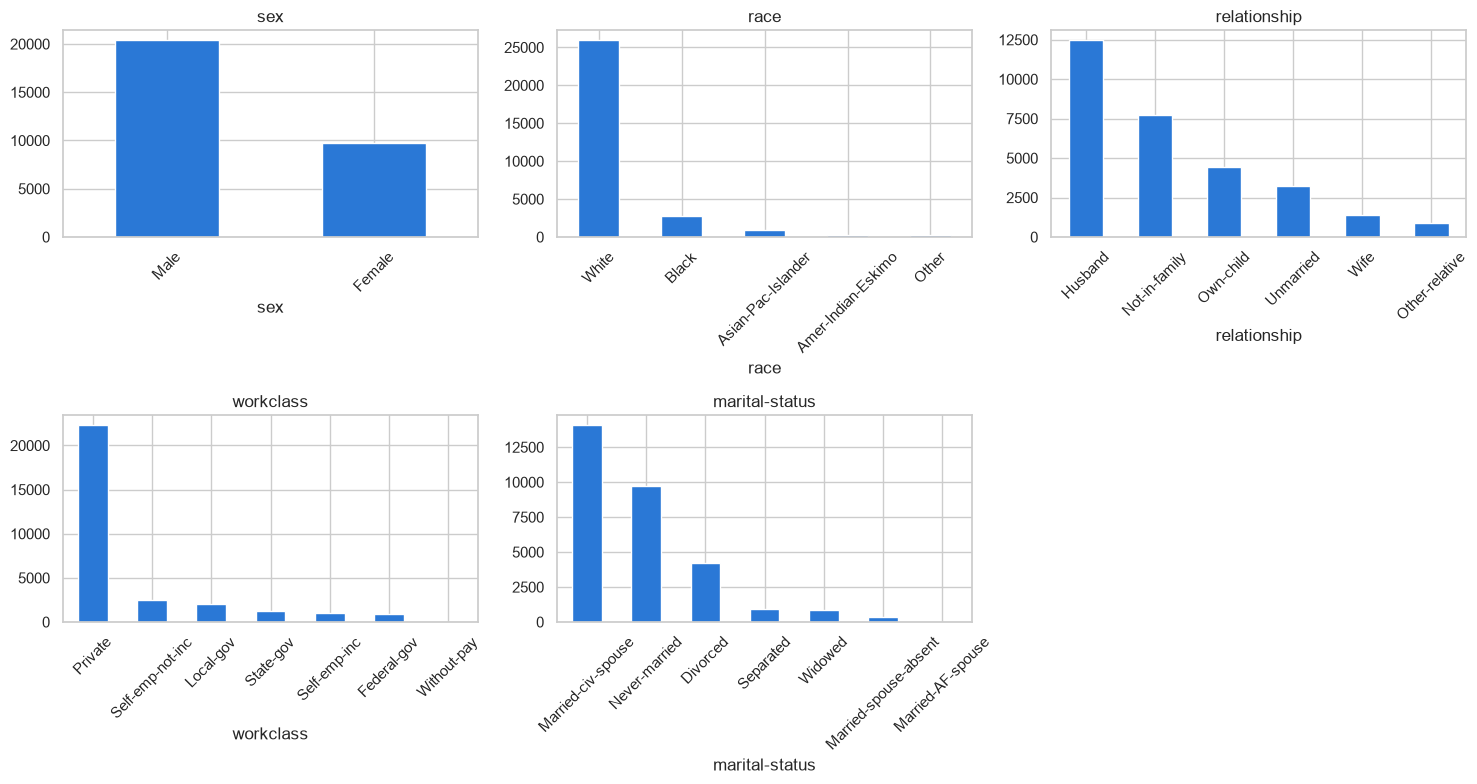

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, low_card.index):
    df[col].value_counts().plot(kind='bar', ax=ax, color="#2a78d6")
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
for ax in axes.flat[len(low_card):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

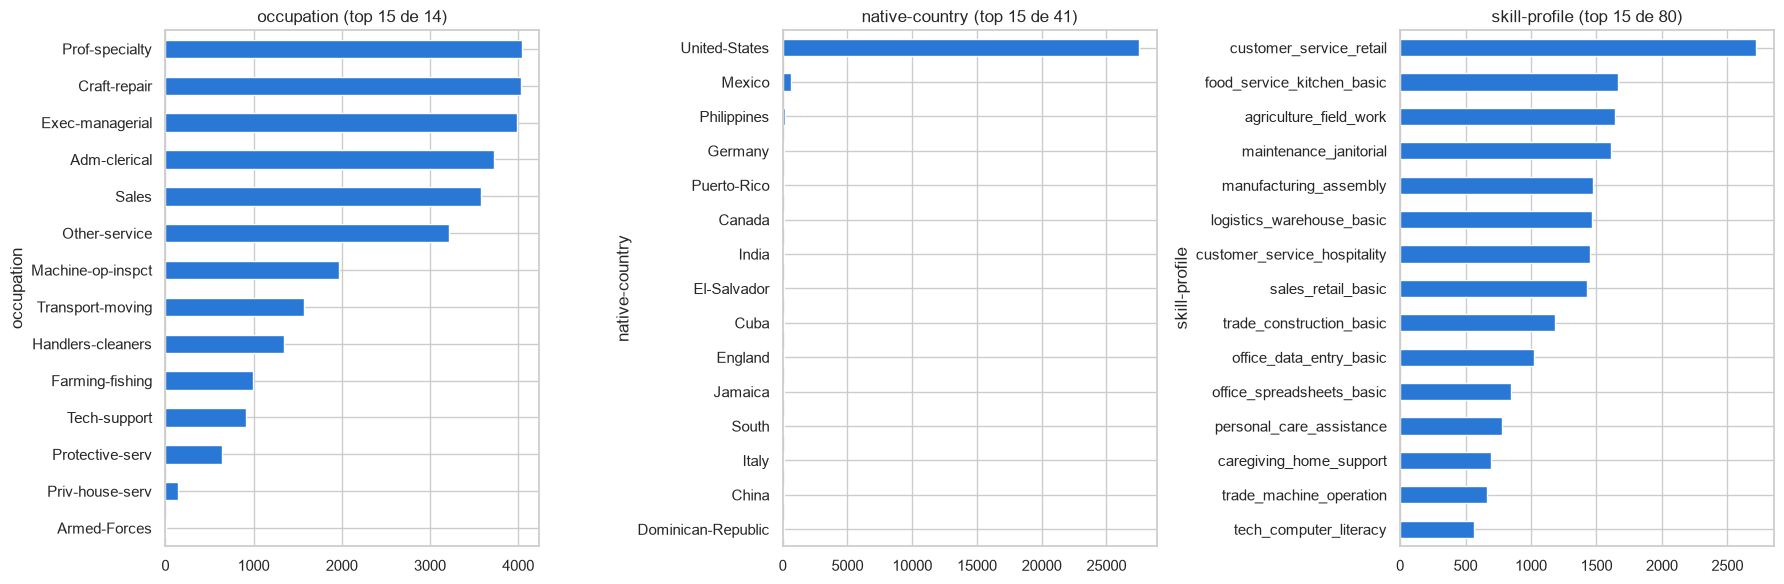

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, high_card.drop('education').index):
    df[col].value_counts().head(15).plot(kind='barh', ax=ax, color="#2a78d6")
    ax.invert_yaxis()
    ax.set_title(f"{col} (top 15 de {df[col].nunique()})")
plt.tight_layout()
plt.show()

### Variables numéricas

Analizamos la distribución de las variables continuas: `age`, `hours-per-week`, `capital-gain` y `capital-loss`.

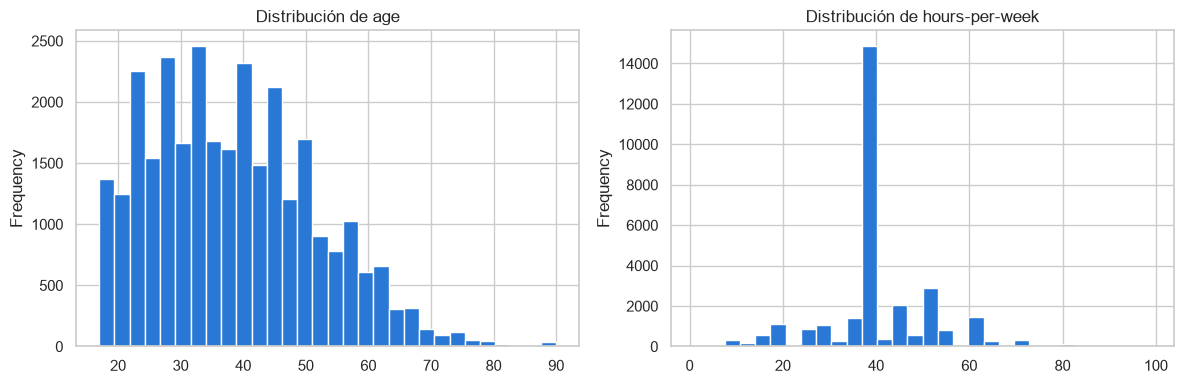

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['age'].plot(kind='hist', bins=30, ax=axes[0], color="#2a78d6", edgecolor='white')
axes[0].set_title('Distribución de age')
df['hours-per-week'].plot(kind='hist', bins=30, ax=axes[1], color="#2a78d6", edgecolor='white')
axes[1].set_title('Distribución de hours-per-week')
plt.tight_layout()
plt.show()

% de filas con capital-gain == 0: 91.6%
% de filas con capital-loss == 0: 95.3%


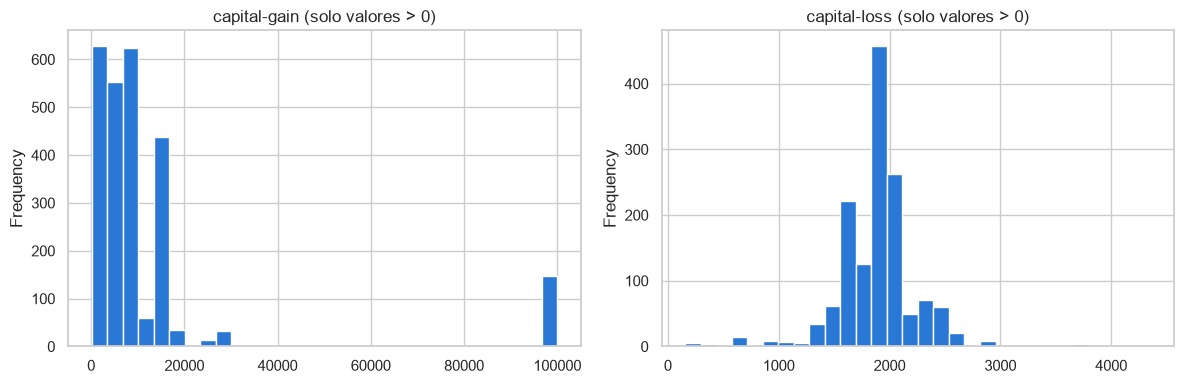

In [13]:
pct_zero_gain = (df['capital-gain'] == 0).mean()
pct_zero_loss = (df['capital-loss'] == 0).mean()
print(f"% de filas con capital-gain == 0: {pct_zero_gain:.1%}")
print(f"% de filas con capital-loss == 0: {pct_zero_loss:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.loc[df['capital-gain'] > 0, 'capital-gain'].plot(kind='hist', bins=30, ax=axes[0], color="#2a78d6", edgecolor='white')
axes[0].set_title('capital-gain (solo valores > 0)')
df.loc[df['capital-loss'] > 0, 'capital-loss'].plot(kind='hist', bins=30, ax=axes[1], color="#2a78d6", edgecolor='white')
axes[1].set_title('capital-loss (solo valores > 0)')
plt.tight_layout()
plt.show()

el 91.6% de las filas tiene `capital-gain = 0` y el 95.3% tiene `capital-loss = 0`. La distribución es casi binaria. Prácticamente la única información que aportan es: ¿tuvo o no ganancia/pérdida de capital?.

### Variable objetivo (`income`)

income
<=50K    22654
>50K      7508
Name: count, dtype: int64
income
<=50K    0.751078
>50K     0.248922
Name: proportion, dtype: float64


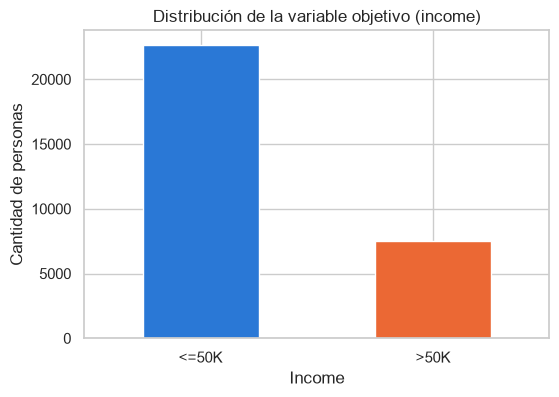

In [14]:
income_counts = df['income'].value_counts()
income_pct = df['income'].value_counts(normalize=True)
print(income_counts)
print(income_pct)

plt.figure(figsize=(6, 4))
income_counts.plot(kind='bar', color=[{"<=50K": "#2a78d6", ">50K": "#eb6834"}[c] for c in income_counts.index])
plt.title('Distribución de la variable objetivo (income)')
plt.xlabel('Income')
plt.ylabel('Cantidad de personas')
plt.xticks(rotation=0)
plt.show()

Dataset test un tanto desbalanceado: ~75.1% de los individuos gana `<=50K` y ~24.9% gana `>50K`.

### Relación entre las variables y la variable objetivo

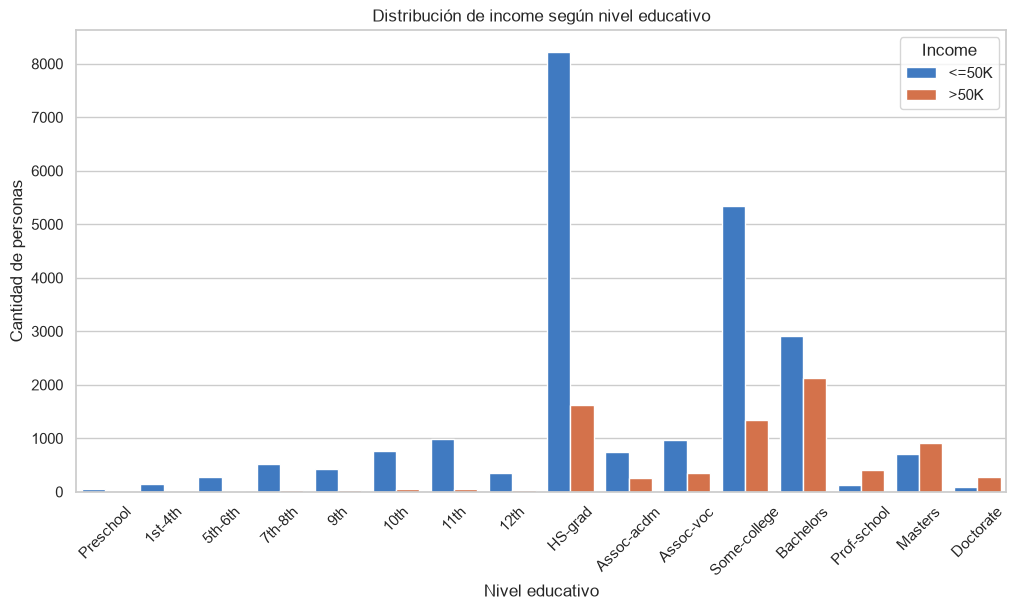

In [15]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='education', hue='income', order=education_categories, palette={"<=50K": "#2a78d6", ">50K": "#eb6834"})
plt.title('Distribución de income según nivel educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Cantidad de personas')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.show()

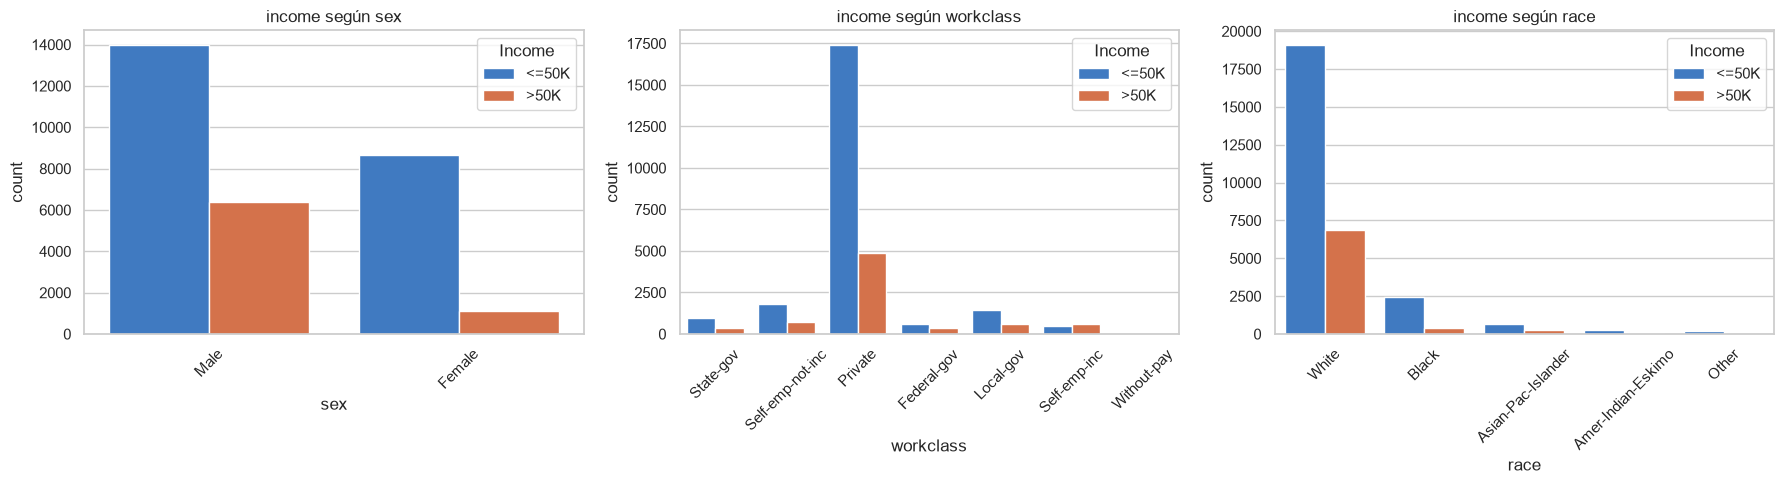

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['sex', 'workclass', 'race']):
    sns.countplot(data=df, x=col, hue='income', ax=ax, palette={"<=50K": "#2a78d6", ">50K": "#eb6834"})
    ax.set_title(f'income según {col}')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Income')
plt.tight_layout()
plt.show()

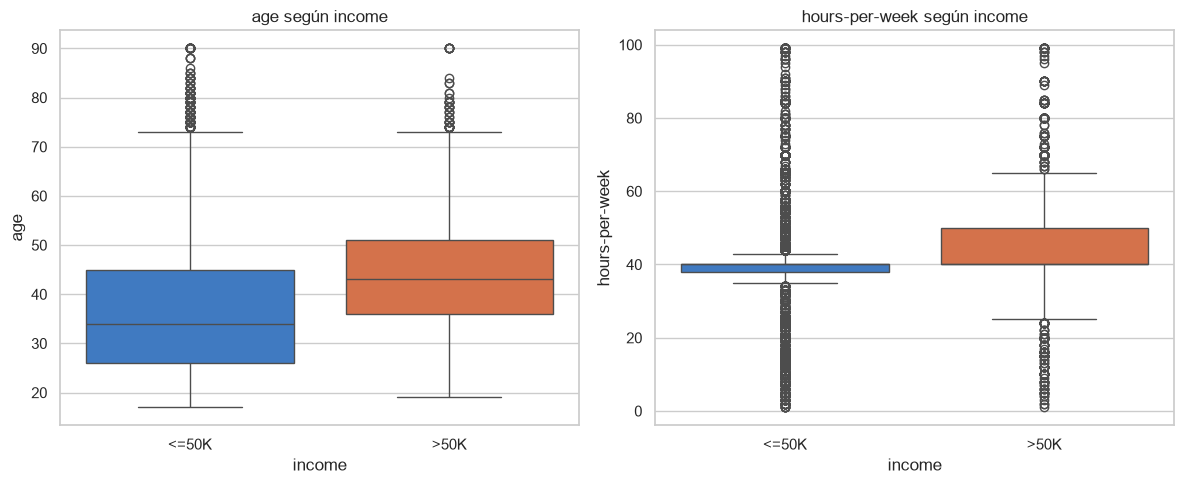

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='income', y='age', hue='income', palette={"<=50K": "#2a78d6", ">50K": "#eb6834"}, legend=False, ax=axes[0])
axes[0].set_title('age según income')
sns.boxplot(data=df, x='income', y='hours-per-week', hue='income', palette={"<=50K": "#2a78d6", ">50K": "#eb6834"}, legend=False, ax=axes[1])
axes[1].set_title('hours-per-week según income')
plt.tight_layout()
plt.show()

### Correlación entre variables numéricas

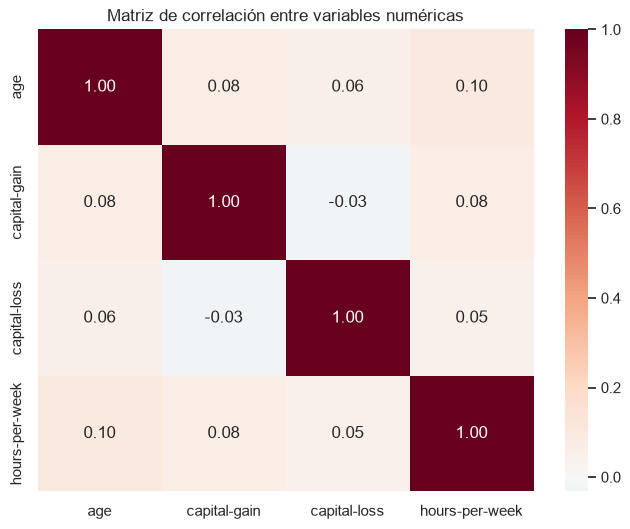

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

## Decisiones de transformación por variable

Variables numéricas contínuas: `age`, `capital-gain`, `capital-loss`, `hours-per-week`, quedan sin codificar. Son valores numéricos nativos que consideramos pueden aportar directamente información al modelo. Se consideró convertir `capital-loss` y `hours-per-week` a boolean, por la cantidad de valores en 0, pero entendimos que quizás se trate de valores faltantes y hacerlo podría despistar al modelo.

Las variables categóricas se separan en:
- baja cardinalidad -> menos de 10 valores únicos
- alta cardinalidad -> más de 10 valores únicos

Variables de baja cardinalidad:
- `sex` e `income` de cardinalidad 2 son casteados a boolean. Operativamente funcionaría igual que one-hot-encoding pero el datatype boolean facilita las operaciones.
- `race`, `relationship`, `workclass` and `marital-status`, por tener baja cardinalidad y ningún orden lógico aplican one-hot-encoding.

Variables de alta cardinalidad:
- `education` se codifica como ordinal porque tiene un order lógico.
- `ocupation`, `native-country` y `skill-profile` se representan mediante embeddings porque tiene demasiados valores únicos (sin un orden lógico) para aplicar one-hot-encoding y se estima que aplicando embeddings puedan aportar información útil al modelo.

### Codificamos..

Aplicamos el tipo de dato `category` de pandas a las variables nominales (incluyendo las de alta cardinalidad que luego usará la capa de embeddings), para un manejo más eficiente de memoria.

In [19]:
df.columns = df.columns.str.strip()
nominal_cols = ['workclass', 'marital-status', 'occupation', 'relationship',
                'race', 'native-country', 'skill-profile']

df[nominal_cols] = df[nominal_cols].astype('category')

Convertimos `education` en una categoría ordinal, usando el orden definido y validado más arriba.

In [20]:
education_order = pd.CategoricalDtype(categories=education_categories, ordered=True)
df['education'] = df['education'].astype(education_order)

Aplicamos one-hot encoding a las columnas de baja cardinalidad (<10 valores únicos, sin orden lógico).

In [21]:
low_card_cols = ['race', 'relationship', 'workclass', 'marital-status']
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

In [22]:
# make sex column binary 'Male' = 1, 'Female' = 0
df['sex'] = (df['sex'].str.strip() == 'Male').astype(int)
df['sex'].value_counts()

sex
1    20380
0     9782
Name: count, dtype: int64

In [23]:
# make 'income' column binary '>50K' = 1, '<=50K' = 0
df['income'] = (df['income'].str.strip() == '>50K').astype(int)
df['income'].value_counts()

income
0    22654
1     7508
Name: count, dtype: int64

`occupation`, `native-country` y `skill-profile` quedan con dtype `category` (aplicado más arriba) y se codificarán mediante una capa de `nn.Embedding` dentro del modelo del punto b).

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.